In [73]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import export_graphviz
import graphviz

In [74]:
df = pd.read_csv("../data/clean_group_data.csv")
target = "is_canceled"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
split_summary = pd.DataFrame({
    "Dataset": ["X_train, y_train", "X_test, y_test"],
    "Observations": [len(y_train), len(y_test)],
    "Cancelled (%)": [
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ],
    "Not Cancelled (%)": [
        (y_train == 0).mean() * 100,
        (y_test == 0).mean() * 100
    ]
}).round(2)

display(split_summary)

,Dataset,Observations,Cancelled (%),Not Cancelled (%)
0,"X_train, y_train",12068,41.77,58.23
1,"X_test, y_test",3018,41.78,58.22


### Functions for evaluating the tree model

In [76]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    # Print metrics
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("Specificity:", tn / (tn + fp))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    print("F2 Score:", fbeta_score(y_test, y_test_pred, beta=2))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=["Not Cancelled", "Cancelled"]
    )

    plt.title("Confusion Matrix")
    plt.show()


def visualize_tree(tree_model, X_train, model_name="tree_model"):
    dot_data = export_graphviz(
        tree_model,
        out_file=None,
        feature_names=X_train.columns,
        class_names=["Not Cancelled", "Cancelled"],
        filled=True,
        rounded=True,
        special_characters=True,
        max_depth=3
    )

    graph = graphviz.Source(dot_data)

    # graph.render(model_name, format="png", cleanup=True) # uncomment this for storing the tree as a PNG file
    
    return graph

def visualize_feature_importance(tree_model, X):
    importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    importance_df.head(5)
    top5 = importance_df.head(5)
    print(top5)

    plt.figure(figsize=(8, 5))
    plt.barh(top5["Feature"][::-1], top5["Importance"][::-1])

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Top 5 Feature Importances")

    plt.tight_layout()
    plt.show()

def plot_roc_comparison(model1, model2, X_test, y_test, model1_name="Model 1", model2_name="Model 2"):
    # Predicted probabilities
    prob1 = model1.predict_proba(X_test)[:, 1]
    prob2 = model2.predict_proba(X_test)[:, 1]

    # ROC values
    fpr1, tpr1, _ = roc_curve(y_test, prob1)
    fpr2, tpr2, _ = roc_curve(y_test, prob2)

    # AUC scores
    auc1 = roc_auc_score(y_test, prob1)
    auc2 = roc_auc_score(y_test, prob2)

    # Plot
    plt.figure(figsize=(8, 6))

    plt.plot(fpr1, tpr1, label=f"{model1_name} (AUC = {auc1:.3f})")

    plt.plot(fpr2, tpr2, label=f"{model2_name} (AUC = {auc2:.3f})")

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.show()

## Part 1 — Default Decision Tree

### 1a. Build the default model

In [77]:
default_tree = DecisionTreeClassifier(random_state=42)
default_tree = default_tree.fit(X_train, y_train)

In [78]:
default_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### 1b. Training and test accuracy

Training Accuracy: 0.9973483592973152
Test Accuracy: 0.7770046388336647
Precision: 0.7367149758454107
Recall: 0.725614591593973
Specificity: 0.8138873079112123
F1 Score: 0.73112265281662
F2 Score: 0.7278078269169583
ROC-AUC: 0.7700118298754681


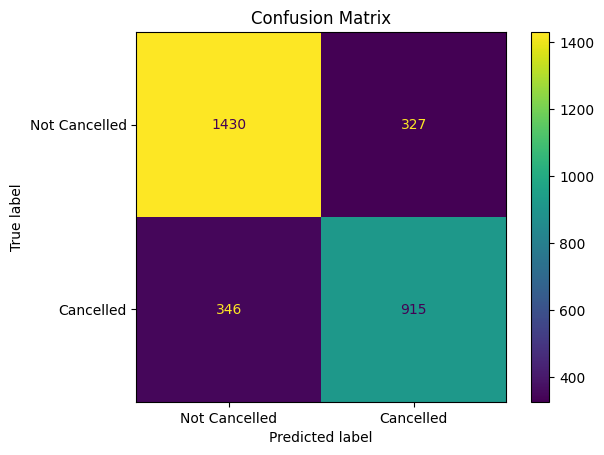

In [79]:
evaluate_model(default_tree, X_train, y_train, X_test, y_test)

### 1c. Tree size / 1d. First and second splits

Tree depth: 36
Total nodes: 3991
Number of leaves: 1996


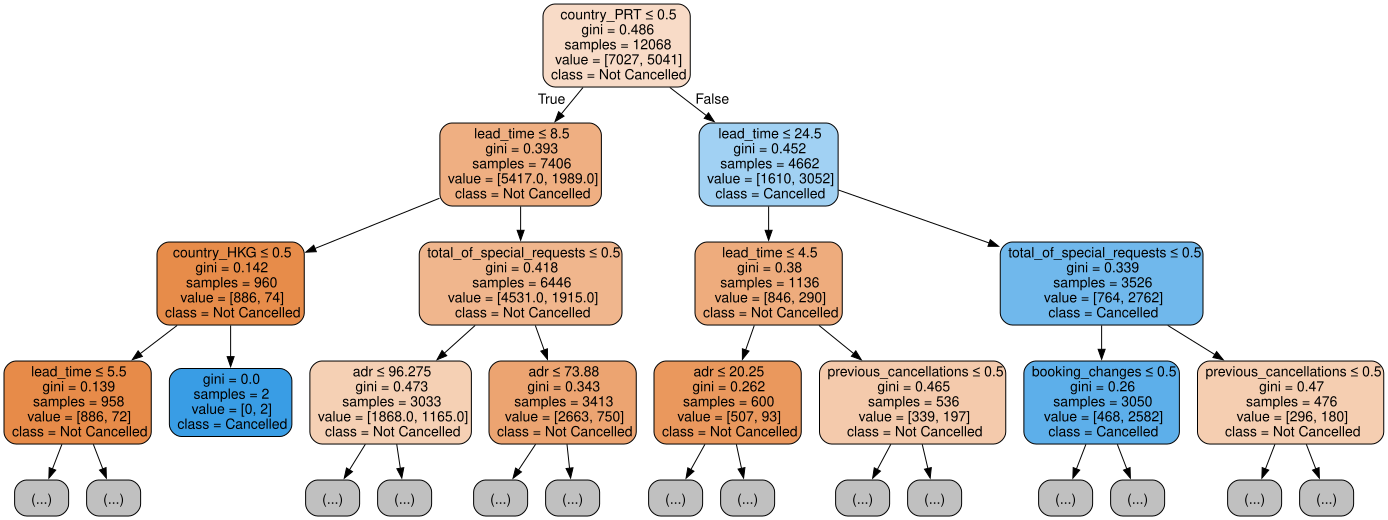

In [80]:
print("Tree depth:", default_tree.get_depth())
print("Total nodes:", default_tree.tree_.node_count)
print("Number of leaves:", default_tree.get_n_leaves())

visualize_tree(default_tree, X_train, model_name="default_tree")

### 1e. Top 5 feature importances

                       Feature  Importance
0                    lead_time    0.214544
123                country_PRT    0.146282
10                         adr    0.138948
1     arrival_date_week_number    0.078134
2    arrival_date_day_of_month    0.076779


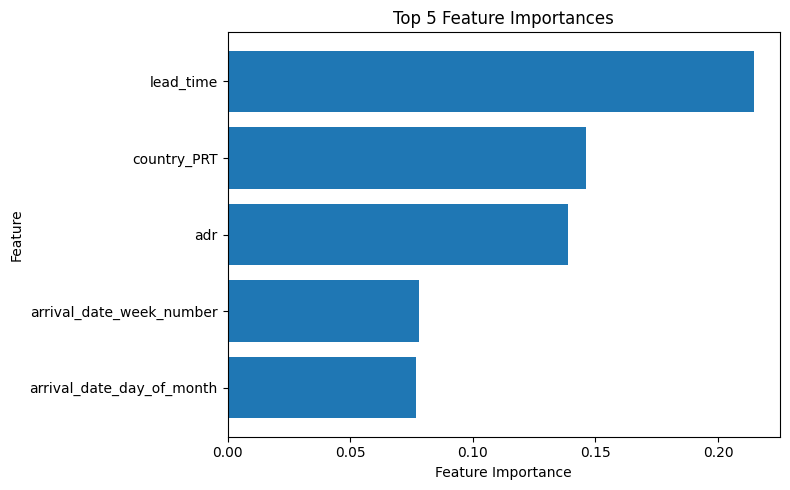

In [81]:
visualize_feature_importance(default_tree, X)

### 1f. Overfitting

The result shows the sign of overfitting with the result of training accuracy is alomst perfect whereas test accuracy is 77 percent. The model's accuracy drops significantly on unseen data. 

## Part 2 — Tuned Decision Tree

### 2a. Grid parameter used

In [82]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [15, 20, 25, 30],
    "max_leaf_nodes": [75, 100, 125, 150, 200],
    "min_samples_leaf": [3, 5, 7, 10],
    "min_samples_split": [15, 20, 25, 30]
}

In [83]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=10,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': 150, 'min_samples_leaf': 7, 'min_samples_split': 25}

Best CV accuracy:
0.794993480539858


### 2b. Training and test accuracy

Training Accuracy: 0.8309579052038448
Test Accuracy: 0.7876076872100729
Precision: 0.7897196261682243
Recall: 0.6701030927835051
Specificity: 0.8719408081957882
F1 Score: 0.725010725010725
F2 Score: 0.6910369643441282
ROC-AUC: 0.8513766391328308


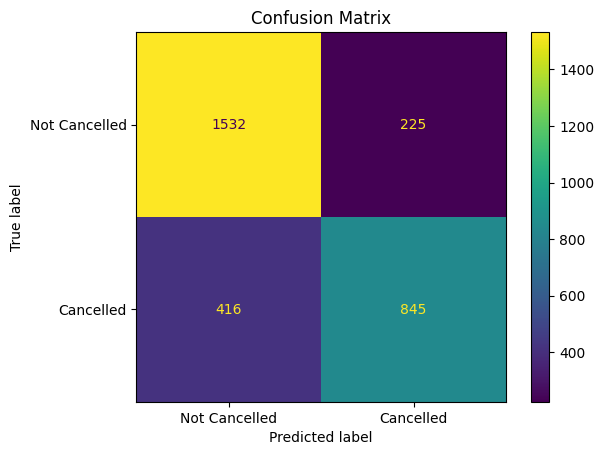

In [84]:
evaluate_model(best_tree, X_train, y_train, X_test, y_test)

### 2c. Tree size / 2d. First and second splits

Tree depth: 18
Total nodes: 299
Number of leaves: 150


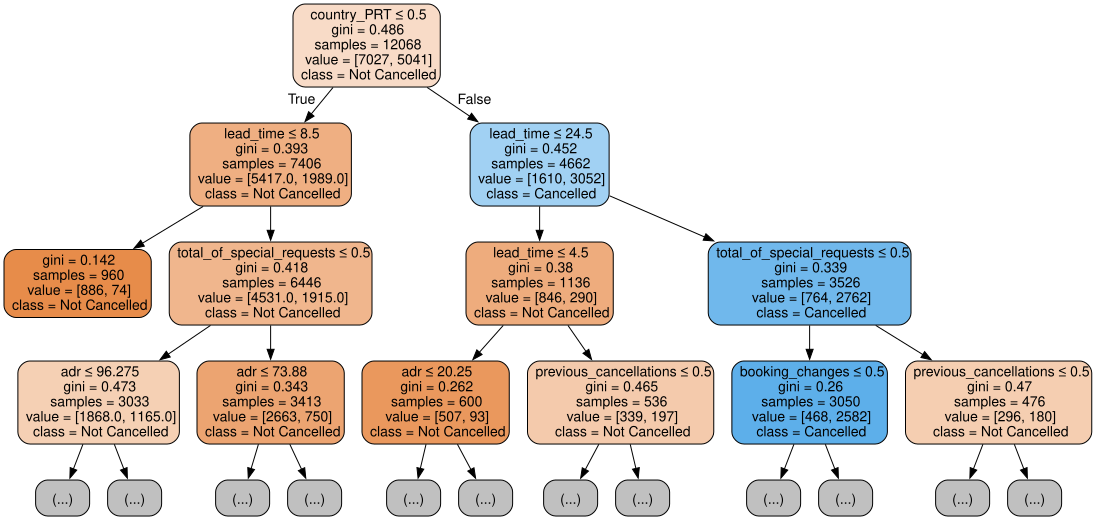

In [85]:
print("Tree depth:", best_tree.get_depth())
print("Total nodes:", best_tree.tree_.node_count)
print("Number of leaves:", best_tree.get_n_leaves())

visualize_tree(best_tree, X_train, model_name="best_tree")

### 2e. Top 5 feature importances

                       Feature  Importance
123                country_PRT    0.290780
0                    lead_time    0.256367
10                         adr    0.107171
11   total_of_special_requests    0.097414
9              booking_changes    0.054012


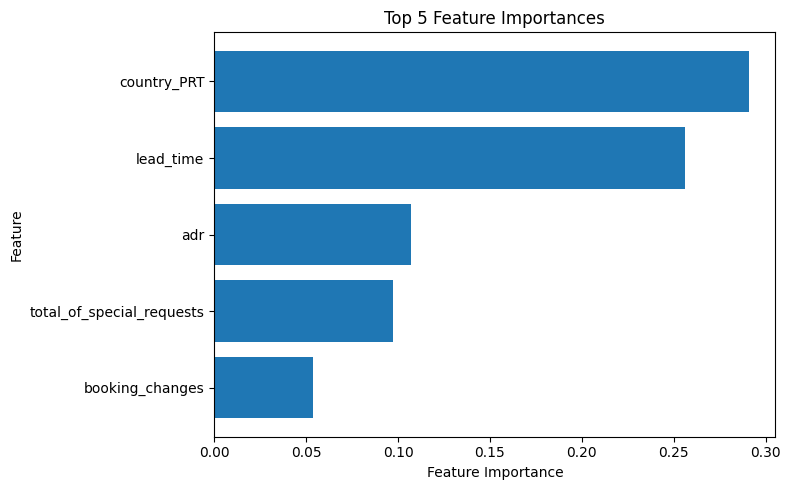

In [86]:
visualize_feature_importance(best_tree, X)

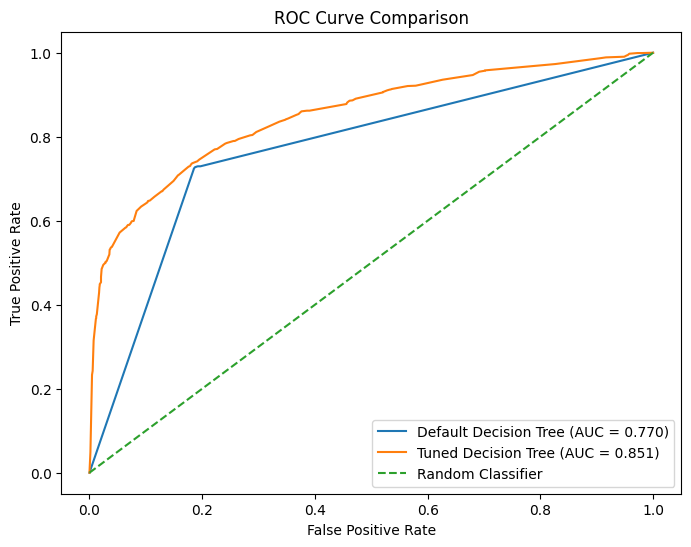

In [87]:
plot_roc_comparison(
    default_tree,
    best_tree,
    X_test,
    y_test,
    "Default Decision Tree",
    "Tuned Decision Tree"
)